In [11]:
import torch
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

In [12]:
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

# Get a model and an image
weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()

preprocess = weights.transforms()
img = decode_image("/Users/wilgotlucaci/Desktop/white-lab.webp")

input_tensor = preprocess(img)

with LayerCAM(model) as cam_extractor:
  out = model(input_tensor.unsqueeze(0))
  # Retrieve the CAM by passing the class index and the model output
  activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)

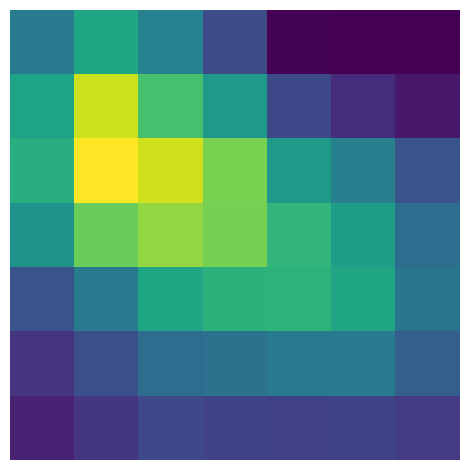

In [13]:
import matplotlib.pyplot as plt
# Visualize the raw CAM
plt.imshow(activation_map[0].squeeze(0).numpy()); plt.axis('off'); plt.tight_layout(); plt.show()

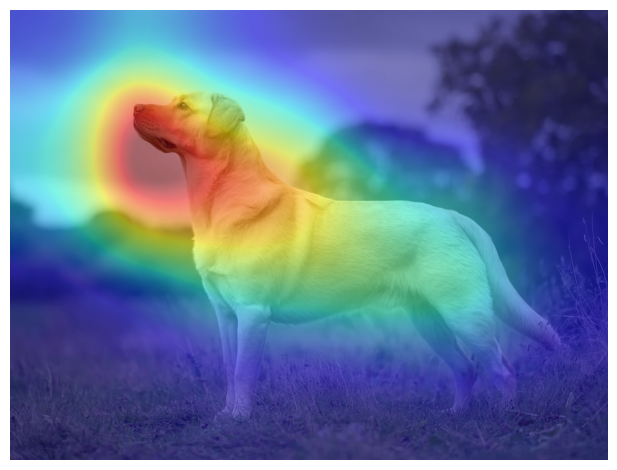

In [14]:
import matplotlib.pyplot as plt
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask

# Resize the CAM and overlay it
result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)
plt.imshow(result); plt.axis('off'); plt.tight_layout(); plt.show()

In [15]:
model.eval()
preprocess = weights.transforms()
batch = preprocess(img).unsqueeze(0)
prediction = model(batch).squeeze(0).softmax(0)

In [16]:
prediction.detach()

tensor([6.8051e-08, 1.2750e-07, 8.5895e-09, 5.0512e-08, 8.0360e-07, 6.8281e-08,
        2.6011e-09, 3.3067e-08, 1.9150e-07, 1.2492e-08, 3.1944e-08, 4.6289e-08,
        4.1859e-08, 2.0643e-08, 6.6581e-09, 2.4834e-10, 5.1250e-08, 5.8370e-07,
        2.8843e-08, 1.3796e-08, 3.4436e-08, 1.8987e-07, 2.7193e-09, 1.9998e-07,
        6.7887e-08, 9.4303e-08, 1.1486e-07, 4.8987e-08, 4.4830e-08, 3.0292e-08,
        3.7267e-08, 1.6606e-08, 2.3856e-08, 1.2544e-07, 7.1019e-08, 1.1937e-07,
        5.9481e-08, 1.1390e-08, 6.3002e-08, 7.8226e-09, 5.5508e-08, 1.6306e-08,
        3.9728e-08, 1.2404e-08, 1.2193e-07, 7.0031e-08, 9.8332e-08, 1.5337e-06,
        2.3342e-07, 1.8201e-08, 1.2240e-08, 1.0061e-07, 6.7017e-07, 6.8183e-07,
        6.8089e-07, 8.2340e-08, 7.1125e-08, 1.9025e-08, 2.6476e-07, 7.6232e-08,
        1.2505e-06, 4.6947e-07, 3.7670e-08, 4.4552e-06, 1.4346e-07, 1.6486e-08,
        7.2658e-07, 1.5612e-06, 2.7905e-07, 7.1204e-08, 1.9703e-08, 1.7533e-07,
        2.7785e-09, 8.8571e-09, 3.2229e-

In [17]:
import json
import torch


def predict_class(output_tensor: torch.Tensor, class_index_path: str) -> dict:
    """
    Maps the maximum logit in a softmax output tensor to an ImageNet class name.

    Args:
        output_tensor:    1D or 2D tensor of shape (1000,) or (1, 1000),
                          typically the output of a softmax layer from ResNet18.
        class_index_path: Path to the imagenet_class_index.json file.

    Returns:
        A dict with keys:
            - 'class_index'  (int)   : index of the predicted class (0–999)
            - 'class_id'     (str)   : WordNet synset ID, e.g. "n01440764"
            - 'class_name'   (str)   : human-readable label, e.g. "tench"
            - 'confidence'   (float) : softmax probability of the top class
    """
    with open(class_index_path, "r") as f:
        class_index = json.load(f)  # keys are str "0".."999"

    # Flatten to 1-D in case the tensor has a batch dimension
    probs = output_tensor.squeeze()          # (1000,)
    if probs.ndim != 1 or probs.shape[0] != 1000:
        raise ValueError(
            f"Expected a tensor of 1000 values, got shape {tuple(output_tensor.shape)}"
        )

    top_idx = int(probs.argmax())            # index of highest probability
    synset_id, class_name = class_index[str(top_idx)]

    return {
        "class_index": top_idx,
        "class_id":    synset_id,
        "class_name":  class_name,
        "confidence":  float(probs[top_idx]),
    }

In [18]:
predict_class(prediction.detach(), "/Users/wilgotlucaci/Downloads/imagenet_class_index.json")

{'class_index': 208,
 'class_id': 'n02099712',
 'class_name': 'Labrador_retriever',
 'confidence': 0.8817296028137207}